Чтение и обработка текста

In [5]:
import pandas as pd
import numpy as np
import csv
import re
from pathlib import Path

label_map = {
    0: "joy",
    1: "sadness",
    2: "surprise",
    3: "fear",
    4: "anger",
}


def read_russian_emotion_file(path, has_header=False):
    rows = []

    with open(path, "r", encoding="utf-8") as file:
        reader = csv.reader(file)

        if has_header:
            next(reader, None)

        for row in reader:
            if len(row) < 3:
                continue

            text = row[0].strip()
            labels_raw = row[1].strip()

            if labels_raw == "[]":
                continue

            labels = re.findall(r"\d+", labels_raw)

            if len(labels) != 1:
                continue

            label_code = int(labels[0])

            if label_code not in label_map:
                continue

            rows.append(
                {
                    "text": text,
                    "label": label_map[label_code],
                    "label_code": label_code,
                }
            )

    return pd.DataFrame(rows)


def find_project_dir():

    current_dir = Path.cwd()

    for path in [current_dir] + list(current_dir.parents):
        if (path / "data" / "russian" / "ru-train.txt").exists():
            return path

    raise FileNotFoundError(
        "Не удалось найти корень проекта. "
        "Проверь, что файл data/russian/ru-train.txt существует."
    )


PROJECT_DIR = find_project_dir()

train_path = PROJECT_DIR / "data" / "russian" / "ru-train.txt"
test_path = PROJECT_DIR / "data" / "russian" / "ru-test.txt"

print("PROJECT_DIR:", PROJECT_DIR)
print("train_path:", train_path)
print("test_path:", test_path)
print("train exists:", train_path.exists())
print("test exists:", test_path.exists())

train_df = read_russian_emotion_file(train_path, has_header=True)
test_df = read_russian_emotion_file(test_path, has_header=False)

print(train_df.head())
print(test_df.head())

PROJECT_DIR: /home/maria/Загрузки/emotion_bot_project
train_path: /home/maria/Загрузки/emotion_bot_project/data/russian/ru-train.txt
test_path: /home/maria/Загрузки/emotion_bot_project/data/russian/ru-test.txt
train exists: True
test exists: True
                                                text     label  label_code
0  У меня остается только один вопрос - является ...  surprise           2
1  Забавно как люди в возрасте удивляются входящи...       joy           0
2  Мы в ужасе от того, что на этот раз был убит ч...      fear           3
3  Все они , к сожалению , для школьников или про...   sadness           1
4  Кому они так необходимы, эти страдания?» А у м...   sadness           1
                                                text     label  label_code
0  Ранее в соцсетях посмеялись над человеком в ко...       joy           0
1  Целый день в дк проторчали) Но повеселились на...       joy           0
2                Сделайте что нибудь удивительное +)       joy           0
3  

In [6]:
from collections import Counter

all_words = []

for text in train_df["text"]:
    words = text.lower().split()
    all_words.extend(words)

word_counts = Counter(all_words)

word_counts.most_common(30)

[(',', 1688),
 ('и', 1285),
 ('в', 1006),
 ('не', 912),
 ('.', 870),
 ('я', 782),
 ('что', 644),
 ('на', 574),
 ('с', 412),
 ('это', 342),
 ('а', 336),
 ('как', 329),
 ('меня', 278),
 ('-', 237),
 ('но', 231),
 ('по', 216),
 ('у', 215),
 ('—', 213),
 ('так', 182),
 ('мне', 175),
 ('за', 174),
 ('все', 173),
 ('к', 171),
 (':(', 167),
 ('он', 163),
 ('очень', 158),
 ('то', 148),
 ('из', 140),
 ('мы', 137),
 ('от', 128)]

In [7]:
print(len(train_df))
print(len(test_df))
print(set(train_df["label"]))
c_em = Counter(train_df["label"])
print(c_em)
print(train_df.isna().sum())
ma = len(max(train_df["text"], key=len))
mi = len(min(train_df["text"], key=len))
train_ma = train_df[train_df["text"].str.len() > ma * 0.95]
train_ma_c = train_ma["label"].tolist()
train_ma_counter = Counter(train_ma_c)
print(train_ma_counter)
train_mi = train_df[train_df["text"].str.len() < mi * 2]
train_mi_c = train_mi["label"].tolist()
train_mi_counter = Counter(train_mi_c)
print(train_mi_counter)
print(test_df.isna().sum())

3309
1069
{'fear', 'joy', 'surprise', 'sadness', 'anger'}
Counter({'joy': 1117, 'sadness': 945, 'surprise': 504, 'fear': 435, 'anger': 308})
text          0
label         0
label_code    0
dtype: int64
Counter({'joy': 1})
Counter({'fear': 6, 'anger': 4, 'joy': 4, 'sadness': 2})
text          0
label         0
label_code    0
dtype: int64


Есть всего 5 основных эмоций: 'surprise', 'sadness', 'anger', 'joy', 'fear'. Распределены они неравномерно: чаще всего стречается счастье, далее грусть, почти в 2 раза реже можно увидеть удивление и страх. Совсем мало злость. Крайне неравмномерные данные. В длинных предложениях такое ра пределение сохраняется, но в коротких лидирует страх. Пустых строк ни в одном файле нет

In [8]:
train_df["text_clean"] = (
    train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

test_df["text_clean"] = (
    test_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
train_df = train_df[train_df["text"] != ""]
test_df = test_df[test_df["text"] != ""]

In [9]:
train_df["label_encoded"] = train_df["label_code"]
test_df["label_encoded"] = test_df["label_code"]
print(train_df[["text", "label", "label_encoded"]].head())
print(test_df[["text", "label", "label_encoded"]].head())

                                                text     label  label_encoded
0  У меня остается только один вопрос - является ...  surprise              2
1  Забавно как люди в возрасте удивляются входящи...       joy              0
2  Мы в ужасе от того, что на этот раз был убит ч...      fear              3
3  Все они , к сожалению , для школьников или про...   sadness              1
4  Кому они так необходимы, эти страдания?» А у м...   sadness              1
                                                text     label  label_encoded
0  Ранее в соцсетях посмеялись над человеком в ко...       joy              0
1  Целый день в дк проторчали) Но повеселились на...       joy              0
2                Сделайте что нибудь удивительное +)       joy              0
3  Ромчик ,ты меня с каждым днем удивляешь  хахах...  surprise              2
4  Мэги Смит удивительная актриса, очень органичн...       joy              0


In [10]:
from sklearn.model_selection import train_test_split

X = train_df["text_clean"]
y = train_df["label_encoded"]
X_test = test_df["text_clean"]
y_test = test_df["label_encoded"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Обучение

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
len(tokenizer.word_index)
list(tokenizer.word_index.items())[:10]

I0000 00:00:1779904228.229476   43356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779904228.230440   43356 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779904228.308453   43356 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779904230.249916   43356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

[('<OOV>', 1),
 ('и', 2),
 ('в', 3),
 ('не', 4),
 ('я', 5),
 ('что', 6),
 ('на', 7),
 ('с', 8),
 ('а', 9),
 ('как', 10)]

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)
print(X_train.iloc[0])
print(X_train_seq[0])
lengths = [len(seq) for seq in X_train_seq]
print(min(lengths))
print(max(lengths))
print(sum(lengths) / len(lengths))
print(np.percentile(lengths, 90))
print(np.percentile(lengths, 95))

террористы взорвали жд вокзал в волгограде..где ж берется столько ненависти и злости?
[1544, 1545, 1546, 1081, 3, 813, 198, 362, 814, 297, 1082, 2, 363]
1
51
12.562523611635815
22.0
25.0


In [13]:
X_train_pad = pad_sequences(
    X_train_seq, maxlen=max_len, padding="post", truncating="post"
)

X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")

X_test_pad = pad_sequences(
    X_test_seq, maxlen=max_len, padding="post", truncating="post"
)
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)
print(X_train.iloc[0])
print(X_train_seq[0])
print(X_train_pad[0])

(2647, 100)
(662, 100)
(1069, 100)
террористы взорвали жд вокзал в волгограде..где ж берется столько ненависти и злости?
[1544, 1545, 1546, 1081, 3, 813, 198, 362, 814, 297, 1082, 2, 363]
[1544 1545 1546 1081    3  813  198  362  814  297 1082    2  363    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [14]:
num_classes = len(label_map)
embedding_dim = 128
filters = 128
kernel_size = 5
dropout_rate = 0.7

model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(units=64, activation="relu"),
        Dropout(dropout_rate),
        Dense(units=num_classes, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

/home/maria/Загрузки/emotion_bot_project/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1779904231.365569   43356 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train_pad, y_train, validation_data=(X_val_pad, y_val), epochs=5, batch_size=32
)

Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3204 - loss: 1.5313 - val_accuracy: 0.3444 - val_loss: 1.4882
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3989 - loss: 1.4369 - val_accuracy: 0.4079 - val_loss: 1.4118
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5897 - loss: 1.1225 - val_accuracy: 0.5060 - val_loss: 1.2436
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7952 - loss: 0.6331 - val_accuracy: 0.5559 - val_loss: 1.2221
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8836 - loss: 0.3550 - val_accuracy: 0.5997 - val_loss: 1.2717


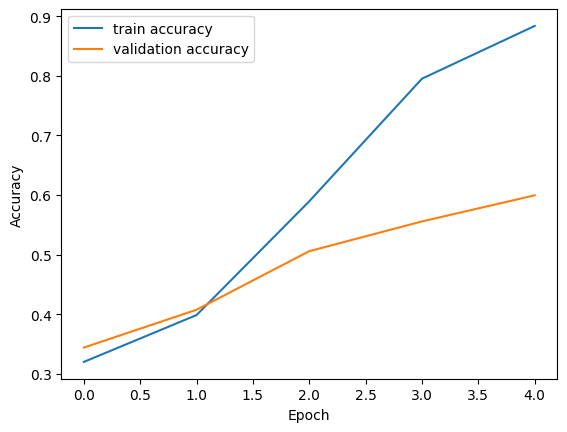

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

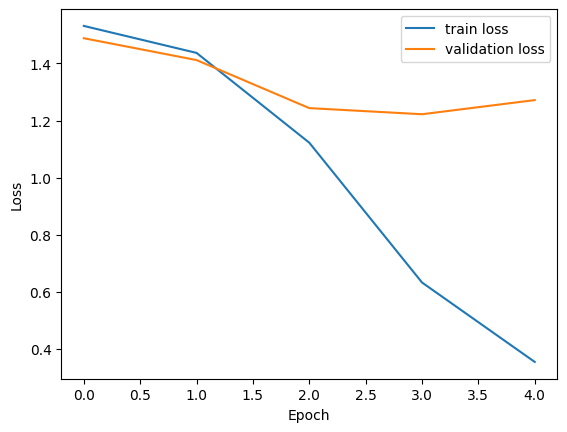

In [17]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [19]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

target_names = [label_map[i] for i in range(len(label_map))]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.6651075771749299
F1 macro: 0.5777600615445151
              precision    recall  f1-score   support

         joy       0.71      0.70      0.71       391
     sadness       0.70      0.70      0.70       420
    surprise       0.48      0.55      0.51        64
        fear       0.68      0.75      0.72       118
       anger       0.28      0.22      0.25        76

    accuracy                           0.67      1069
   macro avg       0.57      0.59      0.58      1069
weighted avg       0.66      0.67      0.66      1069



In [20]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

target_names = [label_map[i] for i in range(len(label_map))]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))

print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.6651075771749299
F1 macro: 0.5777600615445151
              precision    recall  f1-score   support

         joy       0.71      0.70      0.71       391
     sadness       0.70      0.70      0.70       420
    surprise       0.48      0.55      0.51        64
        fear       0.68      0.75      0.72       118
       anger       0.28      0.22      0.25        76

    accuracy                           0.67      1069
   macro avg       0.57      0.59      0.58      1069
weighted avg       0.66      0.67      0.66      1069



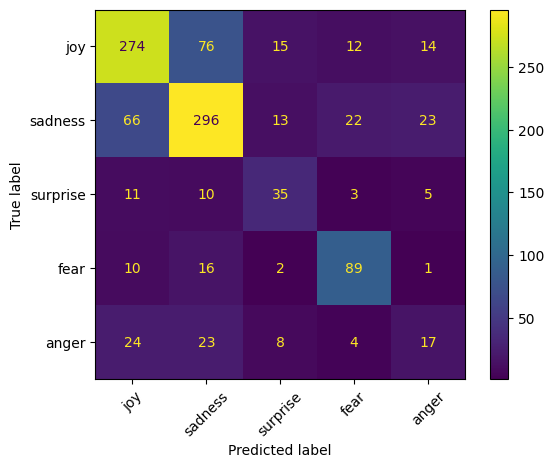

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display_labels = [label_map[i] for i in range(5)]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

disp.plot(xticks_rotation=45)
plt.show()

In [22]:
for i in range(20):
    true_label = label_map[y_test.iloc[i]]
    pred_label = label_map[y_pred[i]]

    if true_label != pred_label:
        print("TEXT:", X_test.iloc[i])
        print("TRUE:", true_label)
        print("PRED:", pred_label)
        print("-" * 50)

TEXT: сделайте что нибудь удивительное +)
TRUE: joy
PRED: surprise
--------------------------------------------------
TEXT: ромчик ,ты меня с каждым днем удивляешь хахаха не перестаю в тебе удивляться я )
TRUE: surprise
PRED: sadness
--------------------------------------------------
TEXT: мэги смит удивительная актриса, очень органично вписалась в эту старинную обстановку)
TRUE: joy
PRED: surprise
--------------------------------------------------
TEXT: скучания ужасные(
TRUE: sadness
PRED: fear
--------------------------------------------------
TEXT: то самое чувство когда тебе скучно, а мне нет) ахаха
TRUE: joy
PRED: sadness
--------------------------------------------------
TEXT: была суровая погода...а леркаа-смерть))))
TRUE: joy
PRED: sadness
--------------------------------------------------
TEXT: это жестоко )
TRUE: joy
PRED: sadness
--------------------------------------------------
TEXT: они переходили дорогу в самых неожиданных местах , застревали на середине проезжей части 